In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import pickle
from src.operations2d import ImageChunk
from src.util import (
    read_video_frames,
    display_image,
    get_character_placeholder,
    read_trimesh,
    trimesh_to_opencv,
    opencv_to_trimesh_pose,
)
from src.operations2d import get_2d_bounding_boxes, bounding_boxes_to_image_chunks, find_similar_image_chunk
from src.operations3d import get_intrinsics_for_chunk, apply_mesh_transforms, adjust_transforms_by_chunk_rotation

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
video_path = "vids/moving_objects/wooden_cabinet.mp4"
frames = read_video_frames(video_path)
previous_frame = frames[0]
next_frame = frames[1]

In [4]:
# read mesh data from pkl
input_pkl = "output/wooden_cabinet.pkl"
with open(input_pkl, 'rb') as f:
            frames_data = pickle.load(f)
            
class_data = frames_data[0]["classes"][0]
object_class = class_data["class_name"]
mesh_data = class_data["reconstructed_meshes"][0]

unposed_path = mesh_data.get("unposed_mesh_path")
scale = mesh_data.get("scale")
rotation = mesh_data.get("rotation")
translation = mesh_data.get("translation")

chunk_relative_scale = mesh_data.get("chunk_relative_scale")
chunk_relative_rotation = mesh_data.get("chunk_relative_rotation")
chunk_relative_translation = mesh_data.get("chunk_relative_translation")

image_chunk_center = mesh_data.get("image_chunk_center")
image_chunk_size = mesh_data.get("image_chunk_size")

Detect objects and get image chunk that is close to previous one

In [6]:
previous_image_chunk = ImageChunk.from_image_point(previous_frame, image_chunk_center, image_chunk_size)

In [6]:
bounding_boxes = get_2d_bounding_boxes(next_frame, object_class)

Running dino in conda environment 'grounding_dino'...
Loading GroundingDINO model...
Using device: cuda
final text_encoder_type: bert-base-uncased
GroundingDINO model loaded.
Saved 1 bounding boxes



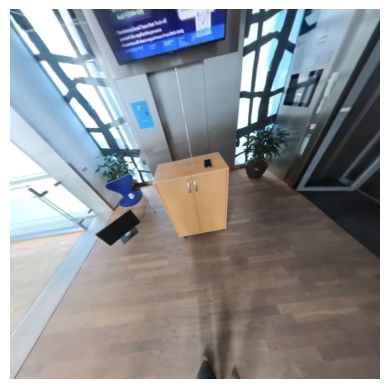

In [7]:
image_chunks = bounding_boxes_to_image_chunks(next_frame, bounding_boxes, orientation="horizontal")
next_image_chunk = find_similar_image_chunk(previous_image_chunk, image_chunks)
display_image(next_image_chunk.image)

In [8]:
import numpy as np
K = np.array([[395.27175903,   0.        , 350.        ],
       [  0.        , 395.27175903, 350.        ],
       [  0.        ,   0.        ,   1.        ]])

Get object mesh in previous pose relative to camera in OpenCV format

In [9]:
import numpy as np

unposed_mesh = read_trimesh(unposed_path)
identity_rotation = np.eye(3, dtype=np.float32)
zero_translation = np.zeros(3, dtype=np.float32)
scaled_mesh = apply_mesh_transforms(unposed_mesh, identity_rotation, zero_translation, chunk_relative_scale)


In [10]:
import cv2

cv_vertices, cv_tris, cv_rotation_mat, cv_translation = trimesh_to_opencv(
    scaled_mesh,
    rotation_matrix=mesh_data.get("chunk_relative_rotation"),
    translation_vector=mesh_data.get("chunk_relative_translation"),
)

cv_rotation, _ = cv2.Rodrigues(cv_rotation_mat)

Run RAPID and apply new transforms to object

In [11]:
# extract contour points
contour_points_2d, contour_points_3d = cv2.rapid.extractControlPoints(
    30,
    50,
    cv_vertices,
    cv_rotation,
    cv_translation,
    K,
    next_image_chunk.image.shape[:2],
    cv_tris,
)

In [12]:
# get the center point in 2d
center_2d = np.mean(contour_points_2d, axis=0)[0]
center_2d

array([353.49646, 366.8363 ], dtype=float32)

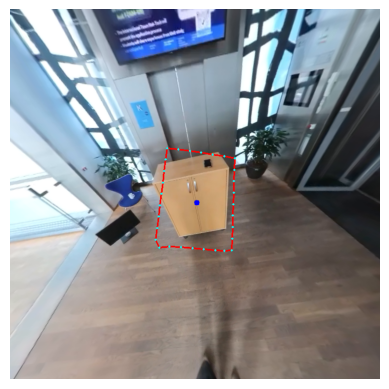

In [13]:
# visualize contour points
contour_overlay = next_image_chunk.image.copy()

contour = contour_points_2d.reshape(-1, 2).astype(np.int32)
cv2.polylines(contour_overlay, [contour], isClosed=True, color=(255, 0, 0), thickness=2)

for pt in contour:
    cv2.circle(contour_overlay, tuple(pt), 2, (0, 255, 255), -1)
    
cv2.circle(contour_overlay, tuple(center_2d.astype(int)), 5, (0, 0, 255), -1)

display_image(contour_overlay)

Do FoundationPose inference to estimate next pose

In [14]:
from src.operations3d import estimate_pose_for_image_chunk
next_rotation_chunk, next_translation_chunk = estimate_pose_for_image_chunk(
    chunk=previous_image_chunk,
    unposed_mesh_path=unposed_path,
    class_name=object_class,
    is_first_frame=True
)

Running sam3 in conda environment 'sam3'...
Loading SAM3 model...
Processed chunk 1/1
Saved 1 masks and boxes

Running foundationpose in conda environment 'foundationpose'...
Warp 1.0.2 initialized:
   CUDA Toolkit 11.5, Driver 12.8
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA L4" (22 GiB, sm_89, mempool enabled)
   Kernel cache:
     /home/ucloud/.cache/warp/1.0.2
num original candidates = 252
num of pose after clustering: 252
Module Utils load on device 'cuda:0' took 6.60 ms



In [20]:
next_translation_chunk

array([707.1063   , 724.9609   ,   1.1194718], dtype=float32)

In [16]:
# Pose in world
rot, trans = adjust_transforms_by_chunk_rotation([next_rotation_chunk], [next_translation_chunk], previous_image_chunk)
next_rotation_world = rot[0]
next_translation_world = trans[0]

Visualize pose difference

In [ ]:
unposed_mesh = read_trimesh(unposed_path)
next_world_mesh = apply_mesh_transforms(unposed_mesh, next_rotation_world, next_translation_world, scale)
unposed_mesh = read_trimesh(unposed_path)
previous_world_mesh = apply_mesh_transforms(unposed_mesh, rotation, translation, scale)

In [25]:
import open3d as o3d
from src.util import trimesh_to_open3d, render_scene
character_placeholder = get_character_placeholder()
coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.55, origin=[0, 0, 0])

render_scene([trimesh_to_open3d(previous_world_mesh).paint_uniform_color([1, 0, 0]),
              trimesh_to_open3d(next_world_mesh).paint_uniform_color([0, 1, 0]),
              character_placeholder,
              coordinate_frame])

Get next chunk

In [36]:
h, w = next_image_chunk.image.shape[:2]
offset_x = center_2d[0] / w - 0.5
offset_y = center_2d[1] / h - 0.5
next_contour_center = (next_image_chunk.center[0] + offset_x, next_image_chunk.center[1] + offset_y)
next_next_image_chunk = ImageChunk.from_image_point(frames[2], next_contour_center, (700, 700))

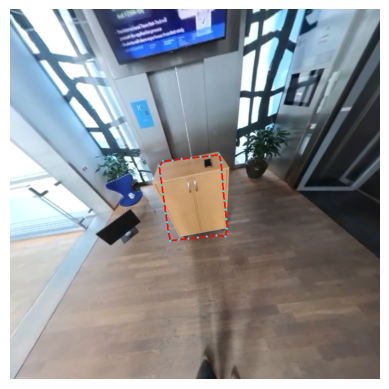

In [82]:
# reproject into frame to check results
new_contour_points_2d, new_contour_points_3d = cv2.rapid.extractControlPoints(
    30,
    50,
    cv_vertices,
    cv_rotation_new,
    cv_translation_new,
    K,
    next_image_chunk.image.shape[:2],
    cv_tris,
)
new_contour_overlay = next_image_chunk.image.copy()
new_contour = new_contour_points_2d.reshape(-1, 2).astype(np.int32)
cv2.polylines(new_contour_overlay, [new_contour], isClosed=True, color=(255, 0, 0), thickness=2)

for pt in new_contour:
    cv2.circle(new_contour_overlay, tuple(pt), 2, (0, 255, 255), -1)
    
display_image(new_contour_overlay)

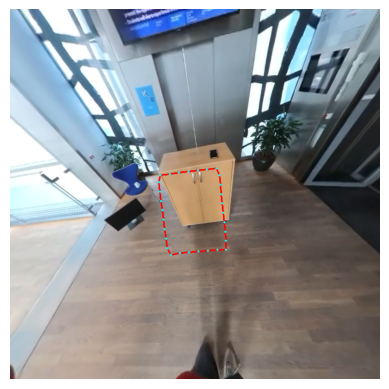

In [49]:
# compare against next frame
new_contour_overlay = next_next_image_chunk.image.copy()
new_contour = new_contour_points_2d.reshape(-1, 2).astype(np.int32)
cv2.polylines(new_contour_overlay, [new_contour], isClosed=True, color=(255, 0, 0), thickness=2)

for pt in new_contour:
    cv2.circle(new_contour_overlay, tuple(pt), 2, (0, 255, 255), -1)
    
display_image(new_contour_overlay)

Adjust by camera movement (rotation + translation)

In [83]:
from src.operations3d import adjust_transforms_by_chunk_rotation

# adjust for changes in chunk position (eg. tracked object is in another position on image sphere than in previous frame)
next_rotation_chunk_chunk_adjusted, next_translation_chunk_chunk_adjusted = adjust_transforms_by_chunk_rotation(
    [next_rotation_world],
    [next_translation_world],
    next_next_image_chunk,
    invert=True
    )

In [84]:
from src.operations3d import adjust_transforms_between_cameras

previous_frame_translation = frames_data[0]["camera_translation"]
previous_frame_rotation = frames_data[0]["camera_rotation"]
next_frame_translation = frames_data[1]["camera_translation"]
next_frame_rotation = frames_data[1]["camera_rotation"]

# adjust for camera rotation and translation between frames
next_rotation_chunk_camera_adjusted, next_translation_chunk_camera_adjusted = adjust_transforms_between_cameras(
    # [next_rotation_chunk],
    # [next_translation_chunk],
    [next_rotation_chunk_chunk_adjusted],
    [next_translation_chunk_chunk_adjusted],
    next_frame_translation,
    next_frame_rotation,
    previous_frame_translation,
    previous_frame_rotation
)

In [85]:
_, _, cv_rotation_mat_new_camera_adjusted, cv_translation_new_camera_adjusted = trimesh_to_opencv(
    scaled_mesh,
    rotation_matrix=next_rotation_chunk_camera_adjusted,
    translation_vector=next_translation_chunk_camera_adjusted,
)

cv_rotation_new_camera_adjusted, _ = cv2.Rodrigues(cv_rotation_mat_new_camera_adjusted)

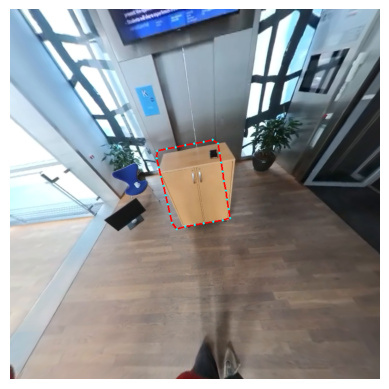

In [86]:
new_contour_points_2d, new_contour_points_3d = cv2.rapid.extractControlPoints(
    30,
    50,
    cv_vertices,
    cv_rotation_new_camera_adjusted,
    cv_translation_new_camera_adjusted,
    K,
    next_next_image_chunk.image.shape[:2],
    cv_tris,
)
new_contour_overlay = next_next_image_chunk.image.copy()
new_contour = new_contour_points_2d.reshape(-1, 2).astype(np.int32)
cv2.polylines(new_contour_overlay, [new_contour], isClosed=True, color=(255, 0, 0), thickness=2)

for pt in new_contour:
    cv2.circle(new_contour_overlay, tuple(pt), 2, (0, 255, 255), -1)
    
display_image(new_contour_overlay)

Do next estimation step

In [ ]:
from src.operations3d import estimate_pose_for_image_chunk
next_next_rotation_chunk, next_next_translation_chunk = estimate_pose_for_image_chunk(
    chunk=next_next_image_chunk,
    unposed_mesh_path=unposed_path,
    class_name=object_class,
    is_first_frame=False
)
rot, trans = adjust_transforms_by_chunk_rotation([next_next_rotation_chunk], [next_next_translation_chunk], next_next_image_chunk)
next_next_rotation_world = rot[0]
next_next_translation_world = trans[0]

In [ ]:
unposed_mesh = read_trimesh(unposed_path)
next_world_mesh = apply_mesh_transforms(unposed_mesh, next_next_rotation_world, next_next_translation_world, scale)
unposed_mesh = read_trimesh(unposed_path)
previous_world_mesh = apply_mesh_transforms(unposed_mesh, next_rotation_world, next_translation_world, scale)

In [ ]:
import open3d as o3d
from src.util import trimesh_to_open3d, render_scene
character_placeholder = get_character_placeholder()
coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.55, origin=[0, 0, 0])

render_scene([trimesh_to_open3d(previous_world_mesh).paint_uniform_color([1, 0, 0]),
              trimesh_to_open3d(next_world_mesh).paint_uniform_color([0, 1, 0]),
              character_placeholder,
              coordinate_frame])